# Open-Meteo Grid Weather Ingestion

Fetches current hourly weather from the **Open-Meteo API** using a coarse 50km sample grid over Victoria, then interpolates all variables down to the **1km `df_grid`** resolution. Utility functions at the end expose per-point, per-postcode, and bounding-box lookups.


## Imports

In [1]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.spatial import cKDTree
from pathlib import Path
from datetime import datetime
import pytz
import geopandas as gpd

## Load Grid

In [2]:
df_grid = pd.read_csv("../../data/grid/victoria_grid_1km.csv")

## Sample Grid

Builds a coarse 50km mesh over Victoria's bounding box. Longitude step is adjusted for latitude (~37°S) to keep cells approximately square. These nodes are the API call targets, fewer points = fewer API requests while still covering the state.

In [3]:
km = 50
lat_step = km / 111
lon_step = km / (111 * np.cos(np.radians(37)))

lats = np.arange(-40.0, -33.5, lat_step)
lons = np.arange(140.0, 151.0, lon_step)
grid_lats, grid_lons = np.meshgrid(lats, lons)

df_sample = pd.DataFrame({
    "lat": grid_lats.ravel(),
    "lon": grid_lons.ravel(),
})
print(f"Cells: {len(df_sample)}")

Cells: 300


## Load POA Boundaries

In [4]:
poa = gpd.read_file("../../data/poa/POA_2021_AUST_GDA2020.shp").set_crs(epsg=4326)
poa_vic = poa[poa["POA_CODE21"].str.startswith("3")]

## Visualize Sample Nodes

Sanity check, confirms sample nodes cover Victoria without obvious gaps or out-of-bound points.

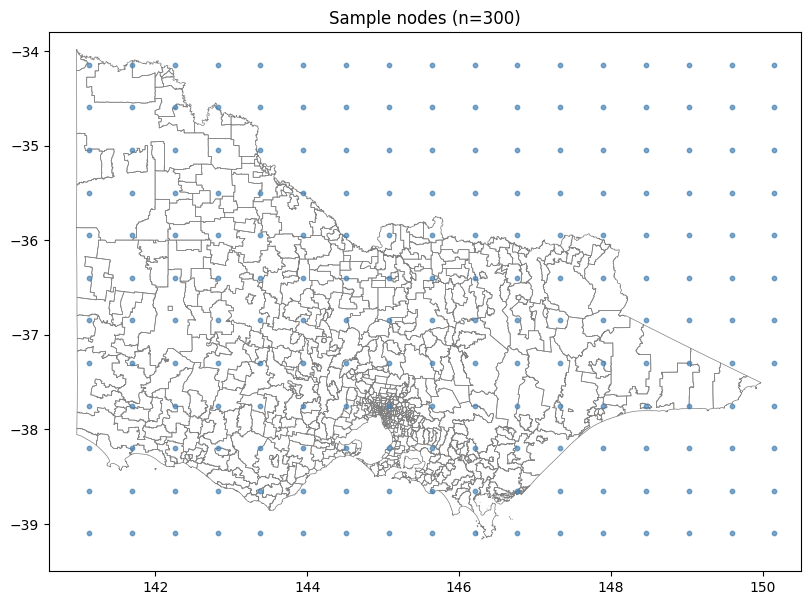

In [5]:
fig, ax = plt.subplots(figsize=(10, 7))
poa_vic.plot(ax=ax, edgecolor="gray", facecolor="none", linewidth=0.5)
ax.scatter(df_sample["lon"], df_sample["lat"], s=10, color="steelblue", alpha=0.7)
ax.set_xlim(140.6, 150.5)
ax.set_ylim(-39.5, -33.8)
ax.set_title(f"Sample nodes (n={len(df_sample)})")
plt.show()

## Fetch Weather

Sends a single batched POST to Open-Meteo with all sample coordinates. The API returns one hourly block per location. We extract the slice closest to the current UTC hour and snap each response coordinate to its nearest `df_grid` point to assign a postcode.

In [6]:
response = requests.post(
    "https://api.open-meteo.com/v1/forecast",
    json={
        "latitude": df_sample["lat"].tolist(),
        "longitude": df_sample["lon"].tolist(),
        "hourly": ["temperature_2m", "relative_humidity_2m", "wind_speed_10m"],
        "forecast_days": 1,
    },
    timeout=60,
)
response.raise_for_status()
payload = response.json()
if isinstance(payload, dict):
    payload = [payload]

now_utc = datetime.now(pytz.utc).replace(minute=0, second=0, microsecond=0)
tz = pytz.timezone("Australia/Melbourne")
now_local = now_utc.astimezone(tz)

rows = []
for loc in payload:
    hourly = loc["hourly"]
    times = pd.to_datetime(hourly["time"]).tz_localize("UTC")
    idx_now = np.abs((times - now_utc).total_seconds()).argmin()

    rows.append({
        "time": now_local.strftime("%Y-%m-%dT%H:%M"),
        "lat": loc["latitude"],
        "lon": loc["longitude"],
        "temperature_2m": hourly["temperature_2m"][idx_now],
        "relative_humidity_2m": hourly["relative_humidity_2m"][idx_now],
        "wind_speed_10m": hourly["wind_speed_10m"][idx_now],
    })

df_weather = pd.DataFrame(rows)
_, idx = cKDTree(df_grid[["lat", "lon"]].values).query(df_weather[["lat", "lon"]].values)
df_weather["postcode"] = df_grid.iloc[idx]["postcode"].values
df_weather

,time,lat,lon,temperature_2m,relative_humidity_2m,wind_speed_10m,postcode
0,2026-04-28T10:00,-39.964850,140.02794,14.6,79,30.5,NaN
1,2026-04-28T10:00,-39.543056,139.98615,14.9,75,27.9,NaN
2,2026-04-28T10:00,-39.050970,140.00000,14.9,79,20.2,NaN
3,2026-04-28T10:00,-38.629173,139.95918,15.1,78,14.5,NaN
4,2026-04-28T10:00,-38.207382,140.04048,15.1,77,12.5,NaN
...,...,...,...,...,...,...,...
295,2026-04-28T10:00,-35.465730,150.69230,18.0,82,8.7,NaN
296,2026-04-28T10:00,-35.043938,150.68703,19.9,60,9.2,NaN
297,2026-04-28T10:00,-34.622143,150.79546,19.3,59,8.7,2540.0
298,2026-04-28T10:00,-34.130054,150.71340,18.6,64,3.5,2540.0


## Visualize Weather Fields

Cubic interpolation over a 200×200 output mesh for each variable. The contour fill is overlaid on POA boundaries to give spatial context.

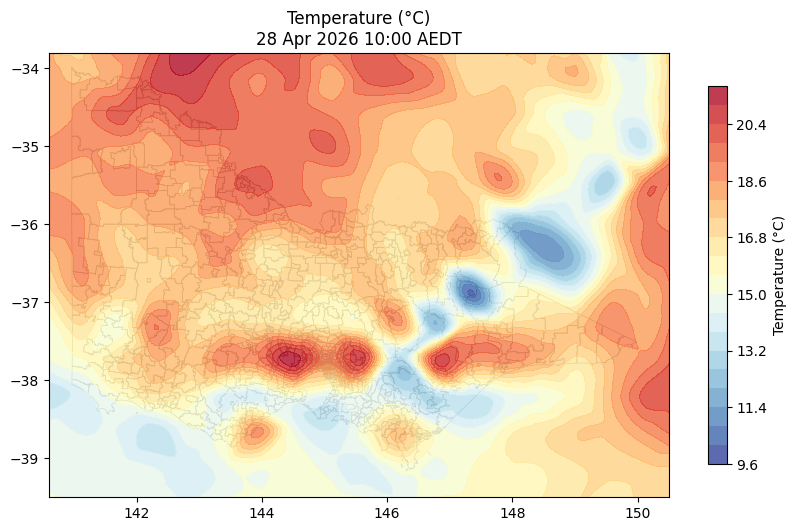

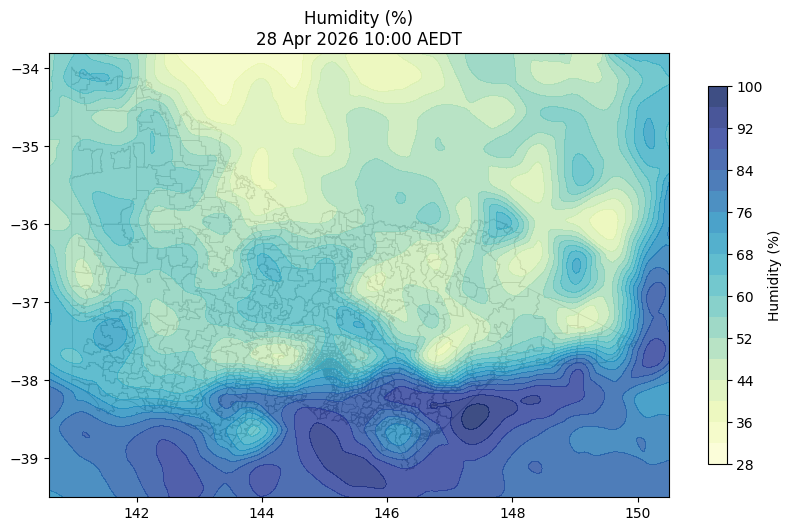

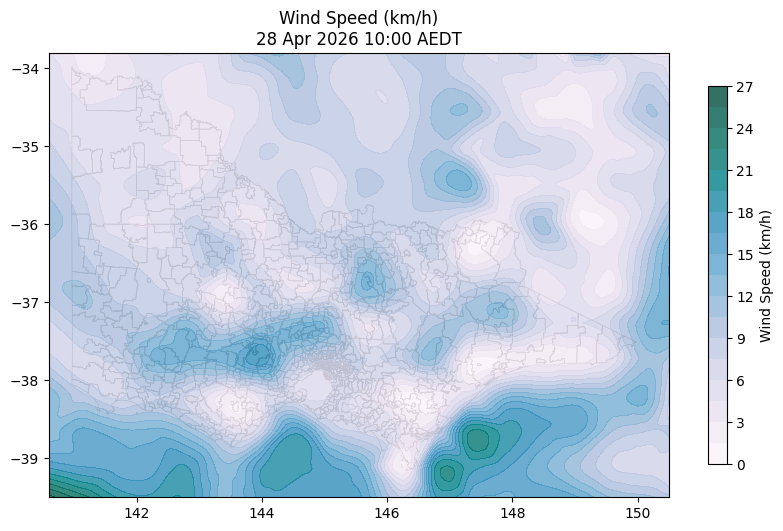

In [7]:
grid_lon, grid_lat = np.meshgrid(
    np.linspace(140.6, 150.5, 200),
    np.linspace(-39.5, -33.8, 200),
)
points = df_weather[["lon", "lat"]].values

VARS = [
    ("temperature_2m", "Temperature (°C)", "RdYlBu_r"),
    ("relative_humidity_2m", "Humidity (%)", "YlGnBu"),
    ("wind_speed_10m", "Wind Speed (km/h)", "PuBuGn"),
]

time_label = pd.to_datetime(df_weather["time"].iloc[0]).strftime("%d %b %Y %H:%M")

for var, label, cmap in VARS:
    z = griddata(points, df_weather[var].values, (grid_lon, grid_lat), method="cubic")

    fig, ax = plt.subplots(figsize=(10, 7))
    poa_vic.plot(ax=ax, edgecolor="gray", facecolor="none", linewidth=0.5)
    cf = ax.contourf(grid_lon, grid_lat, z, levels=20, cmap=cmap, alpha=0.8)
    plt.colorbar(cf, ax=ax, label=label, shrink=0.7)
    ax.set_title(f"{label}\n{time_label} AEDT")
    plt.show()

## Visualize Interpolated Grid

Scatter plot of all 1km grid points coloured by temperature. Validates that the interpolation surface looks spatially coherent at full resolution.

In [8]:
points = df_weather[["lon", "lat"]].values

for var, _, _ in VARS:
    df_grid[var] = griddata(
        points,
        df_weather[var].values,
        df_grid[["lon", "lat"]].values,
        method="cubic"
    )

df_grid

,lat,lon,postcode,temperature_2m,relative_humidity_2m,wind_speed_10m
0,-37.925576,147.967156,NaN,17.260745,75.339920,4.679942
1,-37.934588,147.967275,NaN,17.163298,75.970562,4.926600
2,-37.943600,147.967393,NaN,17.065287,76.599117,5.179633
3,-37.952611,147.967511,NaN,16.966886,77.224913,5.438603
4,-37.961623,147.967629,NaN,16.868271,77.847280,5.703071
...,...,...,...,...,...,...
463801,-38.168499,144.705528,3223.0,15.280732,79.921281,5.479876
463802,-38.381932,150.501182,NaN,19.854760,75.491742,7.177207
463803,-38.189359,145.424190,3981.0,15.015105,83.358486,6.076993
463804,-38.147712,150.501112,NaN,20.190551,74.395453,7.532407


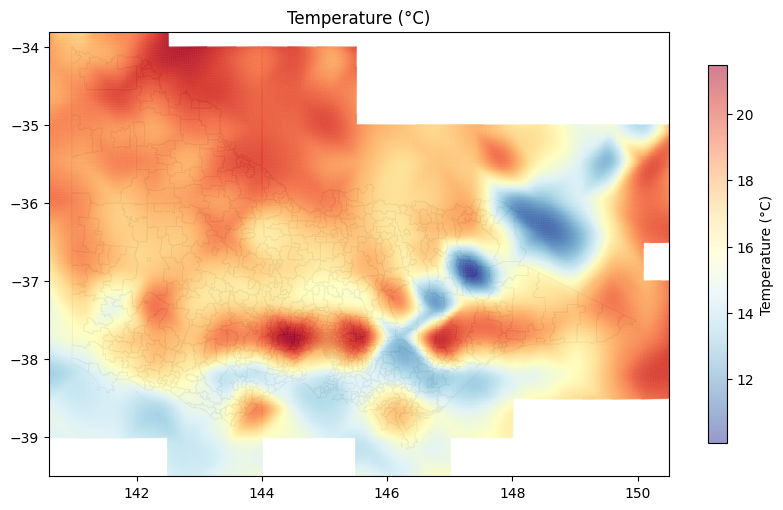

In [9]:
fig, ax = plt.subplots(figsize=(10, 7))
poa_vic.plot(ax=ax, edgecolor="gray", facecolor="none", linewidth=0.5)
sc = ax.scatter(df_grid["lon"], df_grid["lat"], c=df_grid["temperature_2m"], cmap="RdYlBu_r", s=0.1, alpha=0.5)
plt.colorbar(sc, ax=ax, label="Temperature (°C)", shrink=0.7)
ax.set_xlim(140.6, 150.5)
ax.set_ylim(-39.5, -33.8)
ax.set_title("Temperature (°C)")
plt.show()

## Utility Functions

Three lookup helpers built on top of `df_grid`:
- `snap_to_grid` — nearest-neighbour lookup for any lat/lon point
- `get_weather_for_postcode` — mean weather across all 1km cells in a postcode
- `get_weather_for_region` — all grid rows within a lat/lon bounding box

In [10]:
_grid_tree = cKDTree(df_grid[["lat", "lon"]].values)

def snap_to_grid(lat, lon):
    _, idx = _grid_tree.query([lat, lon])
    return df_grid.iloc[idx]

def get_weather_for_postcode(postcode):
    rows = df_grid[df_grid["postcode"] == postcode]
    return rows[["temperature_2m", "relative_humidity_2m", "wind_speed_10m"]].mean()

def get_weather_for_region(lat_min, lat_max, lon_min, lon_max):
    mask = (
        (df_grid["lat"] >= lat_min) & (df_grid["lat"] <= lat_max) &
        (df_grid["lon"] >= lon_min) & (df_grid["lon"] <= lon_max)
    )
    return df_grid[mask]

## Melbourne CBD Sanity Check

In [11]:
result = snap_to_grid(-37.8136, 144.9631)
result

lat                      -37.812849
lon                      144.966484
postcode                3000.000000
temperature_2m            18.530257
relative_humidity_2m      65.820479
wind_speed_10m             6.616638
Name: 273994, dtype: float64